In [1]:
from IPython.display import clear_output
from time import sleep
from datetime import datetime
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 100)
import seaborn as sns
import matplotlib.pyplot as plt
import re
import sqlite3
from contextlib import closing # 
sqlite3.register_adapter(np.int64, lambda val: int(val))
from mycolor import *
import sys
import notebookutil as nbu
sys.meta_path.append(nbu.NotebookFinder())
sys.path.append('C:\\Users\\shiak7\\racepredict') # 自作モジュール用
print("library loading ", datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

library loading  2019/12/05 23:53:21


In [2]:
import sys
sys.path.append('C:\\Users\\shiak7\\racepredict')

In [1]:
# import importlib
# from racelib import myrace
# importlib.reload(mr)
import racelib.myrace as mr

In [71]:
from racelib import fetchQlite
import importlib
importlib.reload(fetchQlite)
from racelib.fetchQlite import FetchQlite

In [72]:
from IPython.display import clear_output
from time import sleep
from datetime import datetime
# import sys
import re
import sqlite3
from contextlib import closing
import numpy as np
sqlite3.register_adapter(np.int64, lambda val: int(val))
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from racelib.fetchQlite import FetchQlite

class Predictions(FetchQlite):
    """
    main class
    """
    def __init__(self):
        pass
    
    def horse_attribution(self, horse):

        def _leading(table, name):
            with closing(sqlite3.connect("racing.sqlite3")) as conn:
                cur = conn.cursor()
                sql = f"Select * From {table} Where Name like?;"
                try:
                    p = re.compile('[\u30A1-\u30FF]+') # 全角カタカナ
                    if p.fullmatch(name) and table=='Jockey':
                        cur.execute(sql, ('%'+name,))
                    else:
                        cur.execute(sql, (name+'%',))
                except sqlite3.Error as e:
                    print('sqlite.Error occurred:', e.arg[0])
                res = cur.fetchall()
                conn.close()
            if(len(res)==1):
                return res[0][3]
            else:
                # print("leading name erorr: Table =", table, f"{name}", len(res))
                return 0.0

        def jockey_leading(name):
#             if(name=='ルメール'):
#                 name='Ｃ．ルメール'
            if(name=='Ｍデムーロ'):
                name='Ｍ．デムーロ'
            if(name=='鮫島駿'):
                name='鮫島克駿'
#             if(name=='シュタルケ'):
#                 name='Ａ．シュタルケ'
#             if(name=='マーフィー'):
#                 name='Ｏ．マーフィー'
            return _leading('Jockey', name)

        def trainer_leading(name):
            if(name=='栗田'):
                name='栗田徹'
            if(name=='高橋博'):
                name='高橋義博'
            if(name=='牧'):
                name='牧光二'
            if(name=='宮'):
                name='宮徹'
            if(name=='和田郎'):
                name='和田正一郎'
            if(name=='森'):
                name='森秀行'
            if(name=='堀'):
                name='堀宣行'
            if(name=='高橋忠'):
                name='高橋義忠'
            if(name=='谷'):
                name='谷潔'
            return _leading('Trainer', name)

        def sire_leading(name):
            return _leading('Sire', name)

        def breeder_leading(name):
            return _leading('Breeder', name)

        Hs = horse['Entry']['Hs']
        horse_name = horse['Entry']['Horse']
        sexage = horse['Entry']['SexAge']
        jockey = horse['Entry']['Jockey']
        trainer = horse['Entry']['Trainer']
        sire = horse['Horse']['Sire']
        _breeder = horse['Horse']['Breeder']
        breeder = _breeder[:10]
        j_leading = jockey_leading(jockey)
        t_leading = trainer_leading(trainer)
        s_leading = sire_leading(sire)
        b_leading = breeder_leading(breeder)
        attr = (str(Hs).rjust(2,"0"), horse_name, sexage, jockey, trainer, sire, breeder)
        leading = (j_leading, t_leading, s_leading, b_leading)
        attribution = [attr, leading]
        return attribution

    def gradeidx(self, racename):
        if('新馬' in racename):
            return 1
        elif('未勝利' in racename):
            return 2
        elif('１勝' in racename or '1勝' in racename or '500万' in racename):
            return 3
        elif('２勝' in racename or '2勝' in racename or '1000万' in racename):
            return 3
        elif('３勝' in racename or '3勝' in racename or '1600万' in racename):
            return 4
        elif('OP' in racename or 'ＯＰ' in racename or '(オープン)' in racename):
            return 5
        elif('(L)' in racename or '(G)' in racename): # ?
            return 6
        elif('G3' in racename):
            return 7
        elif('G2' in racename):
            return 8
        elif('G1' in racename):
            return 9
        else:
            print('gradeidx erorr: not applicable', racename)
            return 5
    
    def newhorse_prediction(self, horsepillar):
        """
        New Horse: (jockey, tariner, father, breeder)
        """
        prediction = []
        for horse in horsepillar:
            attr = self.horse_attribution(horse)
            attribution = attr[0]
            leading = attr[1]
            score = round(np.sum(leading),2)
            leading_data = tuple(map(lambda x : round(x,2), leading))
            idx = ("Hs","Horse","SxAg","Jockey", "Trainer", "Sire", "Breeder", \
                       "Score", "jcky","trar","sire", "brdr")
            data = attribution + (score,) + leading_data
            sr = pd.Series(data, idx)
            prediction.append(sr)
        return prediction

    def promotion_prediction(self, horsepillar):
        """
        Unwinned Horse: (FP x2, favorite x2, margin x2, leading data)
        """
        prediction = []
        for horse in horsepillar:
            attr = self.horse_attribution(horse)
            attribution = attr[0][0:4]
            leading = attr[1]
            df = horse['Performance'].reset_index()
            sample = len(df)
            if(sample !=0):
                """ 着順の(降)など取り除く """
                reFP = [fp if type(fp) != str else int(re.sub("\D", "", fp)) for fp in df['FP']]
                last_FP = 1 - reFP[0]/df['Entry'][0] # 前走着順
                mean_FP = np.mean([1 - fp/en for fp, en in zip(reFP,df['Entry'])]) # 平均着順
                last_fav = 1 - df['Fav'][0]/df['Entry'][0] # 前走人気
                mean_fav = np.mean([1-pop/head for pop, head in zip(df['Fav'],df['Entry'])]) # 平均人気指数
                last_margin = (10 - df['Margin'][0])/10 # 前走着差
                mean_margin = np.mean([(10-margin)/10 for margin in df['Margin']]) # 平均着差
                performance = (last_FP, mean_FP, last_fav, mean_fav, last_margin,mean_margin)
            else:
                performance = (0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
            scoring_data = performance + leading
            score = round(np.sum(scoring_data),2)
            prediction_data = tuple(map(lambda x : round(x,2), scoring_data))
            idx = ("Hs","Horse","SxAg","Jocky", "sp","Score","lsFp","mFp","lsFv",\
                       "mFv","lsMg","mMg","jcky","trar","sire", "brdr")
            data = attribution + (sample, score) + prediction_data
            sr = pd.Series(data, idx)
            prediction.append(sr)
        return prediction

    def op_prediction(self, horsepillar):
        """
        Grade race: (last1rank, last5lank, favorite, margin, jockey, tariner, sire, breeder)
        """
        prediction = []
        for horse in horsepillar:
            attr = self.horse_attribution(horse)
            attribution = attr[0][0:4]
            leading = attr[1]
            df = horse['Performance'].reset_index()
            sample = len(df)
            if(sample !=0):
                grade = self.gradeidx(df['RaceName'][0])/10 + 0.5
                reFP = [fp if type(fp) != str else int(re.sub("\D", "", fp)) for fp in df['FP']]
                last_FP = (1 - reFP[0]/df['Entry'][0]) * grade # 前走着順
                FP_lst =[]
                for i, race, FP, Hc in zip(range(sample),df['RaceName'], reFP, df['Entry']):
                    if(i<5):
                        FP_lst.append( (1-FP/Hc) * (self.gradeidx(race)/10+0.5) )
                mean_FP = np.mean(FP_lst) # 平均着順
                last_fav = (1 - df['Fav'][0]/df['Entry'][0]) * grade # 前走人気
                fav_lst=[]
                for i, race, fav, Hc in zip(range(sample), df['RaceName'],df['Fav'],df['Entry']):
                    if(i<5):
                        fav_lst.append( (1-fav/Hc ) * (self.gradeidx(race)/10+0.5) )
                mean_fav = np.mean(fav_lst) # 平均人気
                last_margin = ((10 - df['Margin'][0])/10) * grade # 前走着差
                margin_lst=[]
                for i, race, margin in zip(range(sample), df['RaceName'], df['Margin']):
                    if(i<5):
                        margin_lst.append( ((10-margin)/10) * (self.gradeidx(race)/10+0.5) )
                mean_margin = np.mean(margin_lst) # 平均着差
                performance = (last_FP, mean_FP, last_fav, mean_fav, last_margin, mean_margin)
            else:
                performance = (0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
        
            scoring_data = performance + leading
            score = round(np.sum(scoring_data),2)
            prediction_data = tuple(map(lambda x : round(x,2), scoring_data))
            idx = ("Hs","Horse","SxAg","Jocky", "sp","Score","lsFp","mFp","lsFv",\
                       "mFv","lsMg","mMg","jcky","trar","sire", "brdr")
            data = attribution + (sample, score) + prediction_data
            sr = pd.Series(data, idx)
            prediction.append(sr)
        return prediction
    
    def predict(self, rc):
        horsepillar = self.makehorsepillar(rc)
        racename = horsepillar[0].Race['RaceName']
        idx = self.gradeidx(racename)
        if(idx<2):
            predicting = self.newhorse_prediction(horsepillar)
        elif(idx==2 or idx==3):
            predicting = self.promotion_prediction(horsepillar)
        elif(idx >3):
            predicting = self.op_prediction(horsepillar)
        else:
            print('grade index error:', idx)
            return []
        entry_df = self.entries_dataframe(rc) # 出走取消を除く
        cancel_df = entry_df[entry_df['Odds']=='取消']
        cancel_horses = cancel_df['Horse'].values
        prediction = [pre for pre in predicting if not pre['Horse'] in cancel_horses]
        return prediction

class VisualizeRace(Predictions):
    def __init__(self):
        self.Crs = '' # Course
        self.Dst = '' # distance

    """ (1) prediction and entrise odds """
    def predictshow(self, RaceCode):
        rc = RaceCode
        lst = self.predict(rc)
        _predict_df = pd.DataFrame(lst).sort_values('Score', ascending=False)
        predict_df = _predict_df.reset_index(drop=True)
        racename, track, cond, holding, detail = self.racenametuple(rc)
        print(racename, track, cond)
        cm = sns.light_palette("green", as_cmap=True)
        display(predict_df.style.background_gradient(cmap=cm)\
                .set_properties(**{'text-align': 'right'}))
        """ 出走表 """
        acqtime = self.fetchacqtime(rc)
        time = acqtime['AcquisitionTime']
        print('取得時間', time)
        _entry_df = self.entries_dataframe(rc)
        _entry_df.where(_entry_df!='', np.nan, inplace=True) # 出走取消の人気蘭をnp.nanにする
        _entry_df.sort_values('Fav', inplace=True)
        entry_df = _entry_df
        #entry_df = _entry_df.reset_index().drop(columns=['index'])
        display(entry_df.style.set_properties(**{'text-align': 'right'}))
        """ グラフ """
        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1)
        plt.rcParams["font.family"] = "IPAexGothic"
        p_bar = predict_df['Score']
        x = range(len(predict_df))
        plt.title(racename, fontsize=16, color="c")
        plt.bar(x, p_bar, color='g')
        plt.subplot(1,2,2)
        odds_sr = entry_df[entry_df['Odds'] != '取消'].Odds
        e_bar = [round((0.8 / odds)*100, 2) for odds in odds_sr]
        plt.title('支持率（オッズ）', fontsize=16, color="c")
        plt.bar(x, e_bar, color='y')
        plt.show()

    """ (2) horse attrbution (newhorse prediction) """
    def horseattribute(self, RaceCode):
        rc = RaceCode
        horsepillar = self.makehorsepillar(rc)
        predicting = self.newhorse_prediction(horsepillar)
        entry_df = self.entries_dataframe(rc) # 出走取消を除く
        cancel_df = entry_df[entry_df['Odds']=='取消']
        cancel_horses = cancel_df['Horse'].values
        prediction = [pre for pre in predicting if not pre['Horse'] in cancel_horses]
        _df = pd.DataFrame(prediction)
        df = _df.sort_values('Hs', ascending=True)
        attrib_df =df.style.background_gradient(cmap=None).set_properties(**{'text-align': 'right'})
        r = self.racenametuple(rc)
        print(r[0], r[1], r[2])
        display(attrib_df)
    
    """ (3) heatmap_performance """
    def color_grade(self, val):
        if '(G1)' in val:
            return 'background-color: #5507FF'
        if '(G2)' in val:
            return 'background-color: #6927FF'
        if '(G3)' in val:
            return 'background-color: #7B3CFF'
        if '(OP)' in val or '(L)' in val or '(G)' in val:
            return 'background-color: #9057FF'
        if '1600' in val or '3勝' in val:
            return 'background-color: #A16EFF'
        if '1000' in val or '2勝' in val:
            return 'background-color: #B384FF'
        if '500' in val or '1勝' in val:
            return 'background-color: #C299FF'  
        else:
            return ''

    def color_course(self, val):
        if self.Crs in val:
            return 'background-color: #99CC00; color: black'
        else:
            return ''

    def color_distance(self, val):
        if self.Dst in val:
            return 'color: orange'
        else:
            return ''

    def color_finish(self, val):
        if self.Crs in val['Holding'] and self.Dst in val['TrkDist']:
            return ['', '', '', '', '', '', '', '', '', '', '', '', '', 'color: red', '', '', '']
        if not self.Crs in val['Holding'] and self.Dst in val['TrkDist']:
            return ['', '', '', '', '', '', '', '', '', '', '', '', '', 'color: orange', '', '', '']
        else:
            return [''] * len(val)

    def heatmaperformance(self, RaceCode):
        rc = RaceCode
        racename, track, cond, holding, detail = self.racenametuple(rc)
        grade = self.gradeidx(racename)
        if grade == 1: # 新馬
            print('New Horse Race is no performance data.')
            return
        self.Dst = track.split(' ')[0].strip('m') # ex:芝2200
        self.Crs = racename.split(' ')[0] # ex:京都
        """ entry_sr + horse_sr, Hs key の辞書 """
        entries = self.fetchentries(rc)
        entry_extend = []
        for entry_sr in entries:
            horse_sr = self.fetchhorse(rc, entry_sr['HorseCode'])
            concat_sr = pd.concat([entry_sr, horse_sr[4:]])
            entry_extend.append(concat_sr)
        horsedic = {}
        for entry_ex in entry_extend:
            horsedic.update({entry_ex['Horse']: entry_ex})
        """ scores + Hs """
        predictions = self.predict(rc)
        scores = []
        jockeyleadingdic = {}
        for pred in predictions:
            scores.append((pred['Score'] , pred['Horse'] ))
            jockeyleadingdic.update({pred['Horse']: pred['jcky']})
        scores.sort(reverse=True)
        """ score付き、score順のhorse data """
        horses = []
        for score, horse in scores:
            horseattr = pd.concat([horsedic[horse], pd.Series([score], ['Score'])])
            horses.append(horseattr)
        """ score順のperformance表示 """
        print(racename, track, cond, '\n')
        for horse in horses:
            print(horse['Hs'], f"{horse['Horse']}({horse['Score']})", horse['SexAge'], end=' ')
            leading = jockeyleadingdic[horse['Horse']]
            print(int(horse['Weight']), f"{horse['Jockey']}({leading})", end=' ')
            print(f"Odds:{horse['Odds']}", f"{horse['Fav']}人", end=' ')
            totalresult = re.sub("\d+戦\d+勝| ", "", horse['TotalResult'])
            print(totalresult, horse['HsWeight'], horse['MainVictory']) # 未勝利戦は勝鞍なし

            _df = self.fetchperformance(rc, horse['HorseCode'])
            df = _df.drop(columns=['id', 'RaceCode', 'HorseCode', 'Horse', 'Bk', 'Hs',\
                                   'Pace', 'HsWeight', 'FirstHorse', 'Prize'])
            df.rename(columns={'Weather':'We', 'Entry':'Hc', 'Fav':'Fv', 'Weight':'Wt', 'Cond':'C', \
                               'Margin':'Mgn','Passing':'Pass', 'Last3h':'L3H'}, inplace=True)
            display(df.style.background_gradient(cmap=None).set_properties(**{'text-align': 'right'})\
                  .applymap(self.color_grade, subset=pd.IndexSlice[:,['RaceName']])\
                  .applymap(self.color_distance, subset=pd.IndexSlice[:,['TrkDist']])\
                  .applymap(self.color_course, subset=pd.IndexSlice[:,['Holding']])\
                  .apply(self.color_finish, axis=1))

In [6]:
#importlib.reload(racelib.tableQlite)
#importlib.reload(racelib.tableQlite)
from racelib.tableQlite import TableQlite

In [3]:
from racelib.scrap2Qlite import Scrap2Qlite

In [42]:
sq = Scrap2Qlite()

In [351]:
for cc in ['中京', '中山', '阪神']:
    for i in range(1,13):
        rc = mr.rc(f"{cc}sat") + str(i).rjust(2,"0")
        # sq.raceQlite(rc)
        sq.updateEntries(rc)
        # sq.resultQlite(rc)
        sleep(2)
        clear_output()
print(cc,i)

阪神 12


In [73]:
#prd = Predictions()
vs = VisualizeRace()

In [608]:
from IPython.display import Image, HTML
img2 = "hanshin-turf1600m.png" # RGBの度合いで緑を50にする
coursename2 = "阪神芝1600m"
mostfav = "1番人気:★★★"
winfoctor = "決め手:(逃)(先)"
text2 = """
<p>牝馬の晴れ舞台である桜花賞と阪神JFが行われるコース。最初のコーナーまでの距離は444m。
外回り682ｍの3～4コーナーを越えた後、474ｍある最後の直線での追い比べとなる。
ゆったりとした流れになることが多く、基本は平均～後傾ラップの瞬発力勝負。
直線ゴール前には高低差1.8ｍの急坂が待ち受けており、京都芝1600m(外回り)に比べて差しが届きやすい。
テン3Fがそれほど速くないにも関わらず下級条件から差し馬の台頭が目立っており、
速い脚を使えれば位置取りはあまり問われない。</p>
"""
display(HTML(""" 
    <style> .block { height: 350px; width: 100%; background-color: #8fbc8f;}
        .inline-block { display: inline-block; vertical-align: middle;}
        .inline-block:nth-child(1) { width: 45% }
        .inline-block img { padding: 10px;}
        .favorite { padding: 10px; float: right; color: #a52a2a; font-size: 16px;
            font-family: "Ricty Diminished";}
        .under { background: linear-gradient(transparent 60%, #2e8b57 50%); text-indent: 2em;
            padding: 10px; color: #000080; font-size: 18px; font-family: "Ricty Diminished"; }
        .inline-block p { padding: 10px; color: #191970; font-size: 16px;
            font-family: "Ricty Diminished"; text-indent: 1em;}
    </style> """))
display(HTML(f"""
        <div class='block'>
        <li class='inline-block'>
        <span class="under">{coursename2}</span>
        <span class="favorite">{favorite} {winfoctor}</span>{text}</li>
        <li class='inline-block'><img src={img}></li>
        </div> """))

In [667]:
def HanshinT2400():
    name = "阪神芝2400m"
    favorite = "1番人気:★★☆"
    winfoctor = "決め手:(逃)"
    img = "./course/hanshin_turf2400.png"
    text = """
    スタート地点は2000mと同じで、こちらは外回りコースを使用。基本はスローの瞬発力勝負で、
    とにかく速い上りが求められ、このコース唯一の重賞である神戸新聞杯では34秒前後の決め手が必須。
    下級条件でも34秒～35秒台のラップが刻まれる。決め手があれば4角のポジションはさほど問われない。
    流れさえ向けばマクリも決まる。
    """
    course = (name, favorite, winfoctor, img, text)
    return course

def HanshinT2200():
    name = "阪神芝2200m"
    favorite = "1番人気:★★★"
    winfoctor = "決め手:(逃)(先)"
    img = "./course/hanshin_turf2200.png"
    text = """
    春のグランプリ・宝塚記念が行われるコースで、外回り4コーナー出口からスタート。
    3～4コーナーは内回りコースを使用。1コーナーまでの距離が525mと長く、スタートが下り坂ということで
    前半は速いラップになりやすい。ただし、向正面からはペースが落ち着き、全体を通してはゆったりとした
    流れになる。前が快調に飛ばすと隊列は縦長になりやすい。内回りのため、瞬発力よりも長くいい脚を使う
    持続力勝負。スピードの出る前半でタメて、後半で前の馬よりもさらに長い脚を使うことが要求される
    差し馬は展開が不利。後方一気も殆ど決まらず、スピードを持続できる先行馬を狙うのがセオリーだ。
    ただし、宝塚記念は例年、テンから緩みないハイペースになることが多く、下級条件とは異なり、
    ラップが大きく前傾するのが特徴。梅雨時で馬場が悪化しやすいことも影響しているのだろう。
    持続力に富んだ差し馬の活躍が目立っている。
    """
    course = (name, favorite, winfoctor, img, text)
    return course

def HanshinT2000():
    name = "阪神芝2000m"
    favorite = "1番人気:★★☆"
    winfoctor = "決め手:(逃)(先)"
    img = "./course/hanshin_turf2000.png"
    text = """
    内回りコース使用。スタンド前直線からスタートし、1コーナーまでの距離は325m。
    スタート直後に上り坂があるため、あまりペースは速くならない。ただし、内回りコースのためか、
    外回りの1600mや1800mほど瞬発力勝負にはならず、むしろゴール前の坂を力強く越えられる
    タフさが要求される。基本は逃げ・先行有利となっており、古馬の上級条件でも馬券の中心は先行馬。
    枠順、メンバー構成からスムーズに先行できそうな馬を狙いたい。そこに穴馬が隠れているかも。
    """
    course = (name, favorite, winfoctor, img, text)
    return course

def HanshinT1800():
    name = "阪神芝1800m"
    favorite = "1番人気:★★★"
    winfoctor = "決め手:(逃)(先)"
    img = "./course/hanshin_turf1800.png"
    text = """
    芝1600mスタート地点から200m下がった2コーナーポケットからスタート。3コーナーまで665ｍと
    たっぷり距離があり、枠順の有利不利は比較的少ない。芝1600mと傾向はだいたい同じだが、
    外回りで直線が長いため、OPクラスでも前半1000m通過が1分超のゆったりした流れになりやすい。
    残り600mからの決め手が勝負のポイント。直線に入る手前から再加速する形となるので、
    緩急に対応できるかどうかが問われる。また、3～4コーナーのカーブは距離が長く、
    大外を回ると距離損になるので、できれば馬群の内に入れて回りたい。
    """
    course = (name, favorite, winfoctor, img, text)
    return course

def HanshinT1600():
    name = "阪神芝1600m"
    favorite = "1番人気:★★☆"
    winfoctor = "決め手:(先)"
    img = "./course/hanshin_turf1600.png"
    text = """
    牝馬の晴れ舞台である桜花賞と阪神JFが行われるコース。最初のコーナーまでの距離は444m。
    外回り682ｍの3～4コーナーを越えた後、474ｍある最後の直線での追い比べとなる。
    ゆったりとした流れになることが多く、基本は平均～後傾ラップの瞬発力勝負。
    直線ゴール前には高低差1.8ｍの急坂が待ち受けており、京都芝1600m(外回り)に比べて差しが届きやすい。
    テン3Fがそれほど速くないにも関わらず下級条件から差し馬の台頭が目立っており、
    速い脚を使えれば位置取りはあまり問われない。
    """
    course = (name, favorite, winfoctor, img, text)
    return course

def HanshinT1400():
    name = "阪神芝1400m"
    favorite = "1番人気:★☆☆"
    winfoctor = "決め手:(逃)"
    img = "./course/hanshin_turf1400.png"
    text = """
    1200mのスタート地点から200m後ろに引いた2コーナー奥のポケットがスタート地点で、内回りコースを使用。
    スタートして平坦～下り坂となるためテンが速くなる傾向がある。
    脚質や枠の特徴は1200mと似ているが、3コーナーまでの距離が443ｍと長くなるためか、揉まれずに行ける
    1枠のアベレージがグンとアップする。また、1200mよりクラスが上がるに連れて差し馬の成績が上昇する。
    2つのコーナーではそれぞれ膨らむため、馬群が横広になりがちで外の馬の距離損は無視できないが、
    最初の長い直線でそれぞれポジションを確保できるため枠順にはさほどこだわる必要はない。
    数頭で雁行した場合に外が不利になる程度である。
    """
    course = (name, favorite, winfoctor, img, text)
    return course

def HanshinT1200():
    name = "阪神芝1200m"
    img = "./course/hanshin_turf1200.png"
    favorite = "1番人気:★☆☆"
    winfoctor = "決め手:(逃)"
    text = """
    向正面半ばからスタートで、3コーナーまでの距離は243m。内回りコースでコーナーまでの距離が短いため、
    枠は内が有利。ただし、揉まれやすい最内枠はマイナス。2枠の数字が頭一つ抜けている。
    スタート直後から緩やかな下りで、残り900mあたりから勾配が増し、直線半ばまで下りが続く。
    ゴール前の直線は350mで、残り約200m地点から上りの急坂が待っている。
    スタートから坂を下ってくるため、勢いの付いた逃げ、先行馬がそのまま押し切るパターンが多く、
    特にAコースは逃げ切りも多い。ただし、前が速くなる上級条件では差しも決まる。
    """
    course = (name, favorite, winfoctor, img, text)
    return course

def HanshinD1200():
    name = "阪神ダ1200m"
    img = "./course/hanshin_dirt1200.png"
    favorite = "1番人気:★★☆"
    winfoctor = "決め手:(逃)"
    text = """
    向正面の2コーナー出口からスタートして3コーナーまでの距離は342m。スタート後200mは平坦で、
    その後は緩い下り坂が続き、ゴール前に急坂が待っている。最後の直線は352m。先行勢が有利。
    ダートの短距離ゆえに前傾ラップとなるのだが、スタート後の直線が短いためか、
    同じ阪神ダート1400mに比べてもそこまでテン争いは激しくならない。
    一方で、最後の急坂が控えるだけに、京都のダート1200mよりは前残りにはなりにくく、
    クラスが上がるとこの傾向が顕著になる。
    """

    course = (name, favorite, winfoctor, img, text)
    return course

def HanshinD1400():
    name = "阪神ダ1400m"
    img = "./course/hanshin_dirt1400.png"
    favorite = "1番人気:★★☆"
    winfoctor = "決め手:(逃)(先)"
    text = """
    ダート1200mのスタート地点からそのまま200m延長した芝のポケット部分がスタート。
    3コーナーまでの距離は542mで、スタートから芝を走るためテンのラップが速くなり、
    同じ阪神でも1200mより速いラップを刻むことが多々ある。逃げ・先行馬が安定しているが、
    先行馬が早めに逃げ馬を潰しに行く展開になると、それらを狙い澄ました差し馬が台頭する。
    枠は芝の部分を長く走れる外枠が有利。この部分は1200mとは違った傾向が出ている。
    """
    course = (name, favorite, winfoctor, img, text)
    return course

def HanshinD1800():
    name = "阪神ダ1800m"
    img = "./course/hanshin_dirt1800.png"
    favorite = "1番人気:★★★"
    winfoctor = "決め手:(逃)(先)"
    text = """
    スタート地点はスタンド前直線にある上り坂の手前で、1コーナーまでの距離は303m。
    コースの形状からは、各馬のポジションが定まる前に1コーナーに入るため、内枠の馬は揉まれてしまう
    ケースが見られる。逃げ・先行馬が有利だが、直線の坂のためか京都ダート1800mに比べて、全体時計、
    上がりともかかる。「スピードの京都、パワーの阪神」は頭に入れておきたい。
    また、早めに前を取りたい馬が殺到してオーバーペースになると差し馬が飛んでくることも。
    逆にペースが緩みすぎるとマクリが決まることもある。レース前半のペース、
    ポジショニングの推理は重要だ。
    """
    course = (name, favorite, winfoctor, img, text)
    return course

def coursedescription(course):
    name = course[0]
    favorite = course[1]
    winfoctor = course[2]
    img = course[3]
    text = course[4]
    if '芝' in name:
        display(HTML(""" <style>
            .block {height:100%; width:100%; background-color:#8fbc8f;}
            .under { background: linear-gradient(transparent 60%, #2e8b57 50%); text-indent: 2em;
                padding: 10px; color: #000080; font-size: 18px; font-family: 'Ricty Diminished'; }
            </style> """))
    if 'ダ' in name:
        display(HTML(""" <style>
            .block {height:100%; width:100%; background-color:#cd853f;}
            .under { background: linear-gradient(transparent 60%, #8b4513 50%); text-indent: 2em;
                padding: 10px; color: #000080; font-size: 18px; font-family: 'Ricty Diminished'; }
            </style> """))
    display(HTML( """ <style>
            .inline-block { display: inline-block; vertical-align: middle;}
            .inline-block:nth-child(1) { width: 45%; }
            .inline-block img { padding: 10px;}
            .favorite { padding: 10px; float: right; color: #a52a2a; font-size: 16px;
                font-family: 'Ricty Diminished';}
            .inline-block p { padding: 10px; color: #191970; font-size: 16px;
                font-family: 'Ricty Diminished'; text-indent: 1em;}
        </style> """))
    
    display(HTML(f"""
            <div class='block'>
            <li class='inline-block'>
            <span class='under'>{name}</span>
            <span class='favorite'>{favorite} {winfoctor}</span>
            <p>{text.strip()}</p></li>
            <li class='inline-block'><img src={img}></li>
            </div> """))

cs = HanshinD1800()
coursedescription(cs)

阪神 4R ２歳未勝利 芝1600m (右)  天気： 馬場： 発走：11:40


,Hs,Horse,SxAg,Jocky,sp,Score,lsFp,mFp,lsFv,mFv,lsMg,mMg,jcky,trar,sire,brdr
0,08,バトーデュシエル,牝2,川田,1,6.96,0.82,0.82,0.91,0.91,1,1,0.57,0.27,0.32,0.34
1,04,マカロンパフェ,牝2,岩田望,2,6.44,0.83,0.86,0.94,0.86,0.98,0.96,0.2,0.23,0.32,0.25
2,09,ミスビアンカ,牝2,福永,1,5.98,0.54,0.54,0.92,0.92,0.88,0.88,0.43,0.21,0.32,0.34
3,11,ステラアルバ,牝2,北村友,1,5.97,0.67,0.67,0.83,0.83,0.91,0.91,0.36,0.2,0.25,0.34
4,10,ゴッドカーヌスティ,牝2,和田,1,5.13,0.33,0.33,0.78,0.78,0.91,0.91,0.26,0.29,0.32,0.23
5,13,カルトレガーメ,牝2,四位,1,5.05,0.56,0.56,0.67,0.67,0.85,0.85,0.27,0.26,0.2,0.18
6,07,ノーブルプリンセス,牝2,藤岡佑,2,5.02,0.5,0.67,0.33,0.39,0.92,0.94,0.29,0.22,0.25,0.5
7,06,フレーヴォ,牝2,松山,1,5.01,0.78,0.78,0.22,0.22,0.96,0.96,0.28,0.27,0.27,0.27
8,12,ダンツイノーバ,牝2,幸,4,4.79,0.77,0.57,0.54,0.29,0.98,0.9,0.25,0.19,0.18,0.11
9,03,プリンセスシューズ,牝2,斎藤,1,4.72,0.31,0.31,0.77,0.77,0.89,0.89,0.23,0.24,0.18,0.14


取得時間 12月07日 10:00:24


,Bk,Hs,Fav,Horse,SexAge,Weight,Jockey,Trainer,HsWeight,Odds
7,6,8,1,バトーデュシエル,牝2,54,川田,安田翔,nan,1.9
5,5,6,2,フレーヴォ,牝2,54,松山,庄野,nan,5.3
3,4,4,3,マカロンパフェ,牝2,52,岩田望,河内,nan,6.1
8,6,9,4,ミスビアンカ,牝2,54,福永,高橋忠,nan,13.7
11,8,12,5,ダンツイノーバ,牝2,54,幸,谷,nan,22.3
0,1,1,6,レイゲツニヤワラグ,牝2,54,荻野極,牧田,nan,22.9
10,7,11,7,ステラアルバ,牝2,54,北村友,牧浦,nan,25.9
2,3,3,8,プリンセスシューズ,牝2,52,斎藤,高柳大,nan,36
6,5,7,9,ノーブルプリンセス,牝2,54,藤岡佑,宮本,nan,37.6
12,8,13,10,カルトレガーメ,牝2,54,四位,武幸,nan,45.6


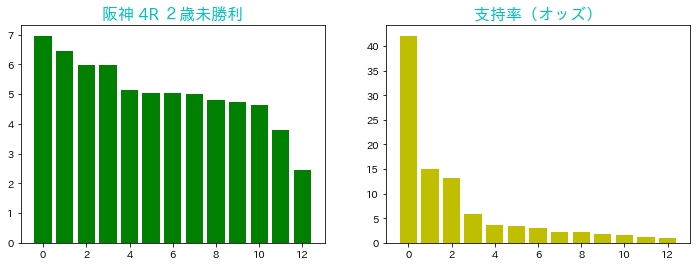

In [432]:
rc = mr.rc('阪神sat') + '04'
vs.predictshow(rc)

In [385]:
vs.horseattribute(rc)

阪神 3R ２歳未勝利 ダ1400m (右)  天気： 馬場： 発走：11:10


,Hs,Horse,SxAg,Jockey,Trainer,Sire,Breeder,Score,jcky,trar,sire,brdr
0,01,クリノルネサンス,牡2,岩田望,高橋忠,パイロ,日西牧場,0.77,0.2,0.21,0.2,0.16
1,02,ヤマカツパトリシア,牝2,国分優,池添学,エイシンフラッシュ,フジワラファーム,0.85,0.12,0.32,0.19,0.21
2,03,コンウィ,牡2,幸,浅見,ロードカナロア,ケイアイファーム,1.09,0.25,0.25,0.32,0.27
3,04,タガノウィリアム,牡2,松田,中尾,パイロ,新冠タガノファーム,0.78,0.19,0.18,0.2,0.21
4,05,バッファローボム,牡2,国分恭,北出,ヴィクトワールピサ,フジワラファーム,0.74,0.15,0.17,0.2,0.21
5,06,ジョーコレット,牡2,斎藤,松下,ジョーカプチーノ,斉藤政志,0.78,0.23,0.21,0.21,0.14
6,07,メイクルーザー,牝2,北村友,森,エスケンデレヤ,下河辺トレーニングセ,0.88,0.36,0.19,0.07,0.26
7,08,トーアヴィルヌーヴ,牝2,川又,牧田,ゴールドアリュール,トーア牧場,0.71,0.19,0.17,0.28,0.07
8,09,マジックスピーチ,牡2,藤岡佑,飯田祐,キズナ,日の出牧場,0.82,0.29,0.25,0.2,0.08
9,10,サイレントスウープ,牝2,川田,安田翔,パイロ,ダーレー・ジャパン・,1.39,0.57,0.27,0.2,0.34


In [386]:
vs.heatmaperformance(rc)

阪神 3R ２歳未勝利 ダ1400m (右)  天気： 馬場： 発走：11:10 

10 サイレントスウープ(5.74) 牝2 54 川田(0.57) Odds:6.0 2人 [0-1-0-1]  


,Date,Holding,We,R,RaceName,Hc,Odds,Fv,FP,Jockey,Wt,TrkDist,C,Finish,Mgn,Pass,L3H
0,19/11/16,5京都5,晴,1,2歳未勝利,13,4.8,2,8,和田竜二,54,ダ1400,良,1:27.7,2.1,4-6,38.8
1,19/09/08,4阪神2,晴,3,2歳新馬,11,1.9,1,2,川田将雅,54,ダ1400,良,1:27.2,0.8,4-3,38.1


14 サンビースト(5.73) 牡2 55 池添(0.27) Odds:2.1 1人 [0-1-0-2]  


,Date,Holding,We,R,RaceName,Hc,Odds,Fv,FP,Jockey,Wt,TrkDist,C,Finish,Mgn,Pass,L3H
0,19/11/09,5京都3,晴,1,2歳未勝利,16,19.6,5,2,池添謙一,55,ダ1400,良,1:25.4,0.7,2-2,38
1,19/09/01,2小倉12,雨,1,2歳未勝利,16,5.6,2,6,松山弘平,54,ダ1700,不,1:49.9,2,3-3-3-2,41
2,19/07/28,2小倉2,晴,5,2歳新馬,11,8.5,5,4,松山弘平,54,芝1200,良,1:10.8,0.9,6-6,36.4


3 コンウィ(5.22) 牡2 55 幸(0.25) Odds:15.5 6人 [0-0-0-2]  


...

,Date,Holding,We,R,RaceName,Hc,Odds,Fv,FP,Jockey,Wt,TrkDist,C,Finish,Mgn,Pass,L3H
0,19/11/16,5京都5,晴,6,2歳新馬,15,60,11,12,中井裕二,55,ダ1200,良,1:16.7,3,7-9,39.7


5 バッファローボム(2.99) 牡2 55 国分恭(0.15) Odds:170.6 14人 [0-0-0-3]  


,Date,Holding,We,R,RaceName,Hc,Odds,Fv,FP,Jockey,Wt,TrkDist,C,Finish,Mgn,Pass,L3H
0,19/11/30,5阪神1,晴,2,2歳未勝利,13,231.2,12,9,松山弘平,55,ダ1400,良,1:28.4,1.1,3-3,39.5
1,19/11/17,5京都6,晴,1,2歳未勝利,16,466.8,15,14,松岡正海,55,ダ1200,良,1:15.9,3.9,15-15,37.4
2,19/11/03,3福島2,晴,5,2歳新馬,15,45.5,12,12,菱田裕二,55,ダ1700,良,1:54.7,5.4,5-6-5-9,42.4


7 メイクルーザー(2.84) 牝2 54 北村友(0.36) Odds:75.2 11人 [0-0-0-2]  


,Date,Holding,We,R,RaceName,Hc,Odds,Fv,FP,Jockey,Wt,TrkDist,C,Finish,Mgn,Pass,L3H
0,19/10/26,4東京8,晴,3,2歳未勝利,15,54.9,9,15,三浦皇成,54,ダ1600,重,1:40.6,3.7,11-11,38.6
1,19/09/16,4阪神5,晴,5,2歳新馬,9,138.9,9,8,亀田温心,51,芝1600,良,1:37.9,2.9,2-2,38.6


In [370]:
fq = FetchQlite()

In [ ]:
rc = mr.rc("東京sat") + "01"

In [438]:
course = ['中京sun', '中山sun', '阪神sun']
race = [str(i).rjust(2,"0") for i in range(1, 12)]
horsepillars = []
for cc in course:
    for r in race:
        rc = mr.rc(cc) + r
        hp = fq.makehorsepillar(rc)
        horsepillars.append(hp)
jockeys=[]
for horsepillar in horsepillars:
    for horse in horsepillar:
        jockeys.append([horse['Race']['Course'], horse['Race']['R'], horse['Entry']['Jockey']\
                       , horse['Entry']['Horse']])
for i, j in enumerate(jockeys):
    if '四位' in j[2] or '蛯名' in j[2]:
        print(j)

['中京', '2R', '蛯名', 'マイネルレンカ']
['中京', '7R', '蛯名', 'エフティクルーク']
['中京', '9R', '蛯名', 'オーロスターキス']
['中京', '11R', '蛯名', 'メモリーコロネット']
['阪神', '3R', '四位', 'ヒルノエドワード']
['阪神', '9R', '四位', 'エーティーラッセン']


In [ ]:
pr = Predictions()

In [ ]:
plt.rcParams["font.family"] = "IPAexGothic"
plt.figure(figsize=(15,20))
for i in range(1,13):
    rc =mr.rc('京都sun') + str(i).rjust(2,"0") 
    p = pr.predict(rc)
    plt.subplot(4,3,i)
    racename = fq.racenametuple(rc)[0]
    bar = sorted([p[i]['Score'] for i in range(len(p))], reverse=True)
    x = range(len(p))
    plt.title(racename, fontsize=16, color="c")
    plt.bar(x, bar)

In [ ]:
fq.racenametuple(rc)[0]

In [ ]:
entries = fq.fetchentries(rc)
d=[]
for entry in entries:
    hc = entry['HorseCode']
    df =fq.fetchperformance(rc, hc).drop(columns=['id', 'Weather',\
                                                      'RaceCode', 'HorseCode', 'Date'])
    d.append(df)

In [ ]:
[f if type(f) != str else int(re.sub("\D", "", f)) for f in d[2]['FP']]

In [ ]:
# import importlib
# importlib.reload(yahoo)
import odds_yahoo as yahoo

In [ ]:
sim = yahoo.Betsimulation(rc)

In [ ]:
sim.show([8])
#sim.simulation(sr,1500)
# sim.wide_series()
#sim.check_payout(rc, df)

In [ ]:
from racelib.fetchQlite import FetchQlite

In [ ]:
fq = FetchQlite()

In [ ]:
rc = mr.rc('阪神sun') + '11'
fq.fetchrace(rc)

In [ ]:
rc

In [ ]:
import sqlite3
conn = sqlite3.connect("racing.sqlite3")
cur = conn.cursor()
cur.execute("SELECT * From race")
row = cur.fetchall()
for r in row:
    print(r)
conn.close()

In [ ]:
fq.entries_dataframe(rc)

In [ ]:
rc
rc[:10]